<a href="https://colab.research.google.com/github/Thowhid01/Impact-of-Financial-News-Sentiment-on-Stock-Price-Movement-Evidence-from-Dhaka-Stock-Exchange/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# Installing all libraries
!pip install pandas numpy matplotlib seaborn scikit-learn -q
!pip install statsmodels tensorflow transformers -q
!pip install torch sentencepiece openpyxl plotly tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print(' All libraries installed!')

 All libraries installed!


In [43]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/DSE_Thesis'
FOLDERS = [
    'data/raw',
    'data/processed',
    'models',
    'results',
    'figures'
]
for f in FOLDERS:
    os.makedirs(f'{BASE}/{f}', exist_ok=True)

print(f' Folder structure ready at: {BASE}')
print('Folders created:')
for f in FOLDERS:
    print(f'   {BASE}/{f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Folder structure ready at: /content/drive/MyDrive/DSE_Thesis
Folders created:
   /content/drive/MyDrive/DSE_Thesis/data/raw
   /content/drive/MyDrive/DSE_Thesis/data/processed
   /content/drive/MyDrive/DSE_Thesis/models
   /content/drive/MyDrive/DSE_Thesis/results
   /content/drive/MyDrive/DSE_Thesis/figures


In [44]:
import zipfile
import pandas as pd
import io
from tqdm.auto import tqdm

ZIP_PATH = f'{BASE}/data/raw/Bangla_fin_news.zip'

all_dfs = []
errors  = []

print(' Reading all  CSV files from ZIP...')


with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    print(f'Total CSV files found: {len(csv_files)}')

    for fname in tqdm(csv_files, desc='Loading files'):
        try:
            with z.open(fname) as f:
                df_temp = pd.read_csv(
                    f,
                    encoding='utf-8',
                    on_bad_lines='skip'
                )
                all_dfs.append(df_temp)
        except Exception as e:
            errors.append((fname, str(e)))

# Combining everything
df_news = pd.concat(all_dfs, ignore_index=True)

print(f'\n Combined DataFrame shape: {df_news.shape}')
print(f'Columns: {df_news.columns.tolist()}')
print(f'Files with errors (skipped): {len(errors)}')
df_news.head(3)

 Reading all  CSV files from ZIP...
Total CSV files found: 7695


Loading files:   0%|          | 0/7695 [00:00<?, ?it/s]


 Combined DataFrame shape: (7730, 5)
Columns: ['Serial', 'Title', 'Date', 'Author', 'News']
Files with errors (skipped): 0


,Serial,Title,Date,Author,News
0,1,শেয়ারবাজারে ব্যাংকগুলোর বিনিয়োগের হিসাব ক্রয়...,2022-08-05,ইত্তেফাক রিপোর্ট,এখন থেকে শেয়ারবাজারে ব্যাংকগুলোর বিনিয়োগের হ...
1,10,জুলাইয়ে রপ্তানি প্রবৃদ্ধি ১৫ শতাংশ,2022-08-03,ইত্তেফাক রিপোর্ট,অর্থবছরের শুরুতে রপ্তানিতে সুখবর মিলল। চলতি ২০...
2,100,তিতা খাওয়াই বাঁশও পাঠাই,2022-07-03,সাইদুল ইসলাম,বাংলাদেশ থেকে রপ্তানি করা পণ্যের সংখ্যা কত এ প...


In [45]:
# ── Cleaning the combined news dataset ──────────────────────────────
print('Before cleaning:', df_news.shape)
print('Missing values:\n', df_news.isnull().sum())


df_news['Date'] = pd.to_datetime(df_news['Date'], errors='coerce')

# Droping rows with no date or no news text
df_news.dropna(subset=['Date', 'News'], inplace=True)
df_news.drop_duplicates(subset=['Title', 'Date'], inplace=True)
df_news.reset_index(drop=True, inplace=True)

print(f'\nAfter cleaning: {df_news.shape}')
print(f'Date range: {df_news["Date"].min().date()} → {df_news["Date"].max().date()}')
print(f'Total unique days with news: {df_news["Date"].dt.date.nunique()}')

# Quick article count per year
print('\nArticles per year:')
print(df_news['Date'].dt.year.value_counts().sort_index())

Before cleaning: (7730, 5)
Missing values:
 Serial     0
Title      4
Date      35
Author    35
News      67
dtype: int64

After cleaning: (7469, 5)
Date range: 2014-03-03 → 2022-08-05
Total unique days with news: 2591

Articles per year:
Date
2014     801
2015    1349
2016     934
2017     757
2018     557
2019     630
2020     718
2021    1110
2022     613
Name: count, dtype: int64


In [46]:
SAVE_PATH = f'{BASE}/data/raw/bangla_financial_news_combined.csv'
df_news.to_csv(SAVE_PATH, index=False, encoding='utf-8-sig')
print(f' Combined news saved!')
print(f'Path: {SAVE_PATH}')
print(f'Total articles: {len(df_news):,}')

 Combined news saved!
Path: /content/drive/MyDrive/DSE_Thesis/data/raw/bangla_financial_news_combined.csv
Total articles: 7,469


In [47]:
DSE_PATH = f'{BASE}/data/raw/DSE_Data.csv'

df_stock = pd.read_csv(DSE_PATH)
print('Raw columns:', df_stock.columns.tolist())
print('Shape:', df_stock.shape)
df_stock.head()

Raw columns: ['Trading_Code', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Shape: (1523921, 7)


,Trading_Code,Date,Open,High,Low,Close,Volume
0,SIBL,2025-04-08,9.9,10.0,9.8,9.9,359773.0
1,MEGHNALIFE,2025-04-08,54.5,56.6,54.1,56.1,610711.0
2,BPML,2025-04-08,41.1,41.7,40.0,40.2,482031.0
3,CROWNCEMNT,2025-04-08,47.9,50.9,47.5,50.0,104860.0
4,ATCSLGF,2025-04-08,0.0,0.0,0.0,7.5,0.0


In [48]:
col_map = {}
for col in df_stock.columns:
    c = col.strip().lower()
    if 'date' in c or 'time' in c:  col_map[col] = 'Date'
    elif c in ['open','opening']:   col_map[col] = 'Open'
    elif c in ['high','highest']:   col_map[col] = 'High'
    elif c in ['low','lowest']:     col_map[col] = 'Low'
    elif 'close' in c:              col_map[col] = 'Close'
    elif 'volume' in c or 'vol' in c: col_map[col] = 'Volume'

df_stock.rename(columns=col_map, inplace=True)
df_stock['Date'] = pd.to_datetime(df_stock['Date'], errors='coerce')
df_stock.dropna(subset=['Date'], inplace=True)
df_stock.sort_values('Date', inplace=True)
df_stock.reset_index(drop=True, inplace=True)

print('Standardized columns:', df_stock.columns.tolist())
print(f'Date range: {df_stock["Date"].min().date()} → {df_stock["Date"].max().date()}')
print(f'Total rows: {len(df_stock):,}')

# Save
df_stock.to_csv(f'{BASE}/data/raw/dse_stock_clean.csv', index=False)
print(' Stock data saved!')
df_stock.head()

Standardized columns: ['Trading_Code', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Date range: 1999-01-02 → 2025-04-08
Total rows: 1,523,921
 Stock data saved!


,Trading_Code,Date,Open,High,Low,Close,Volume
0,APEXSPINN,1999-01-02,109.5,109.5,107.25,109.00,0.0
1,BOC,1999-01-02,94.0,97.0,94.00,95.30,6650.0
2,SINGERBD,1999-01-02,1372.0,1375.0,1360.00,1368.00,85.0
3,UTTARAFIN,1999-01-02,199.0,199.0,197.00,197.50,200.0
4,BDAUTOCA,1999-01-02,75.0,76.0,75.00,75.75,325.0


In [49]:
news_start  = df_news['Date'].min().date()
news_end    = df_news['Date'].max().date()
stock_start = df_stock['Date'].min().date()
stock_end   = df_stock['Date'].max().date()

overlap_start = max(news_start, stock_start)
overlap_end   = min(news_end,   stock_end)

print('='*50)
print(f'News data:   {news_start}  →  {news_end}')
print(f'Stock data:  {stock_start}  →  {stock_end}')
print('='*50)
print(f' Overlap:  {overlap_start}  →  {overlap_end}')

overlap_days = (pd.Timestamp(overlap_end) - pd.Timestamp(overlap_start)).days
print(f'Total overlapping days: {overlap_days}')

if overlap_days < 30:
    print(' Very little overlap ')
else:
    print(' Good overlap ')

News data:   2014-03-03  →  2022-08-05
Stock data:  1999-01-02  →  2025-04-08
 Overlap:  2014-03-03  →  2022-08-05
Total overlapping days: 3077
 Good overlap 


In [50]:
BASE   = '/content/drive/MyDrive/DSE_Thesis'
FIG    = f'{BASE}/figures'
PROC   = f'{BASE}/data/processed'

In [51]:
df = pd.read_csv(f'{BASE}/data/raw/dse_stock_clean.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nBasic statistics:')
df.describe()

Shape: (1523921, 7)

Column types:
Trading_Code            object
Date            datetime64[ns]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Volume                 float64
dtype: object

Missing values:
Trading_Code    0
Date            0
Open            0
High            0
Low             0
Close           0
Volume          2
dtype: int64

Basic statistics:


,Date,Open,High,Low,Close,Volume
count,1523921,1.523921e+06,1.523921e+06,1.523921e+06,1.523921e+06,1.523919e+06
mean,2016-04-22 09:14:17.446810112,2.575521e+02,2.613157e+02,2.536027e+02,8.004094e+02,6.714025e+05
min,1999-01-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2011-10-23 00:00:00,1.810000e+01,1.840000e+01,1.780000e+01,1.875000e+01,6.000000e+03
50%,2017-03-30 00:00:00,4.440000e+01,4.500000e+01,4.360000e+01,4.550000e+01,5.861800e+04
75%,2021-12-01 00:00:00,1.724000e+02,1.750000e+02,1.699000e+02,1.807500e+02,3.155095e+05
max,2025-04-08 00:00:00,1.037500e+06,1.037500e+06,1.037500e+06,1.037500e+06,2.953927e+08
std,NaN,1.430205e+03,1.435162e+03,1.424985e+03,2.324263e+04,5.387557e+06


In [52]:
df.ffill(inplace=True)
df.dropna(inplace=True)

Q1 = df['Close'].quantile(0.01)
Q3 = df['Close'].quantile(0.99)
before = len(df)
df = df[(df['Close'] >= Q1) & (df['Close'] <= Q3)]
after = len(df)
df.reset_index(drop=True, inplace=True)

print(f'Rows before outlier removal: {before}')
print(f'Rows after  outlier removal: {after}')
print(f'Rows removed: {before - after}')
print(f'\nFinal date range: {df["Date"].min().date()} → {df["Date"].max().date()}')

Rows before outlier removal: 1523921
Rows after  outlier removal: 1493744
Rows removed: 30177

Final date range: 1999-01-02 → 2025-04-08


In [53]:
# Moving Averages
df['MA_7']  = df['Close'].rolling(7).mean()
df['MA_30'] = df['Close'].rolling(30).mean()
df['MA_90'] = df['Close'].rolling(90).mean()

# Price-based features
df['Daily_Return']  = df['Close'].pct_change()
df['Volatility_7']  = df['Daily_Return'].rolling(7).std()
df['Volatility_30'] = df['Daily_Return'].rolling(30).std()
df['High_Low_Range'] = df['High'] - df['Low']
df['Price_Change']   = df['Close'] - df['Open']
df['Price_Change_Pct'] = df['Price_Change'] / df['Open'] * 100

# RSI — Relative Strength Index (momentum indicator)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

df['RSI_14'] = compute_rsi(df['Close'], 14)

# MACD — Moving Average Convergence Divergence
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Drop rows with NaN (from rolling calculations)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset with all features: {df.shape}')
print(f'Features created: {df.columns.tolist()}')

Dataset with all features: (1493655, 19)
Features created: ['Trading_Code', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'MA_7', 'MA_30', 'MA_90', 'Daily_Return', 'Volatility_7', 'Volatility_30', 'High_Low_Range', 'Price_Change', 'Price_Change_Pct', 'RSI_14', 'MACD', 'MACD_Signal']


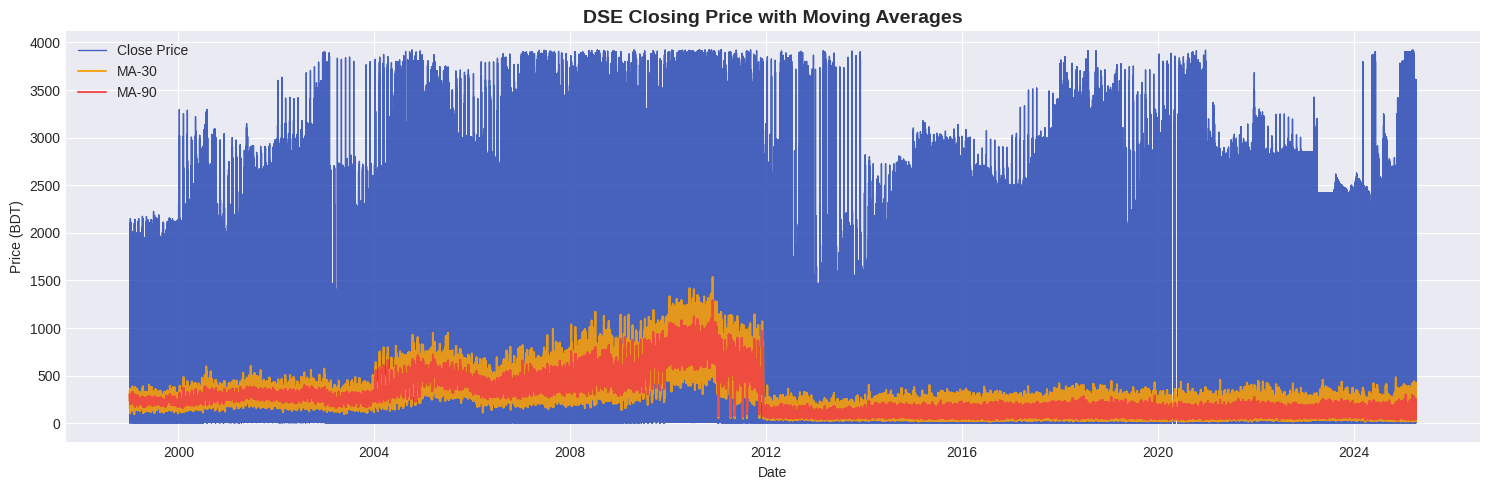

 Figure 1 saved


In [54]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df['Date'], df['Close'],  color='#1e40af', linewidth=1,   label='Close Price', alpha=0.8)
ax.plot(df['Date'], df['MA_30'],  color='#f59e0b', linewidth=1.5, label='MA-30',  alpha=0.9)
ax.plot(df['Date'], df['MA_90'],  color='#ef4444', linewidth=1.5, label='MA-90',  alpha=0.9)

ax.set_title('DSE Closing Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (BDT)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG}/01_price_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 1 saved')

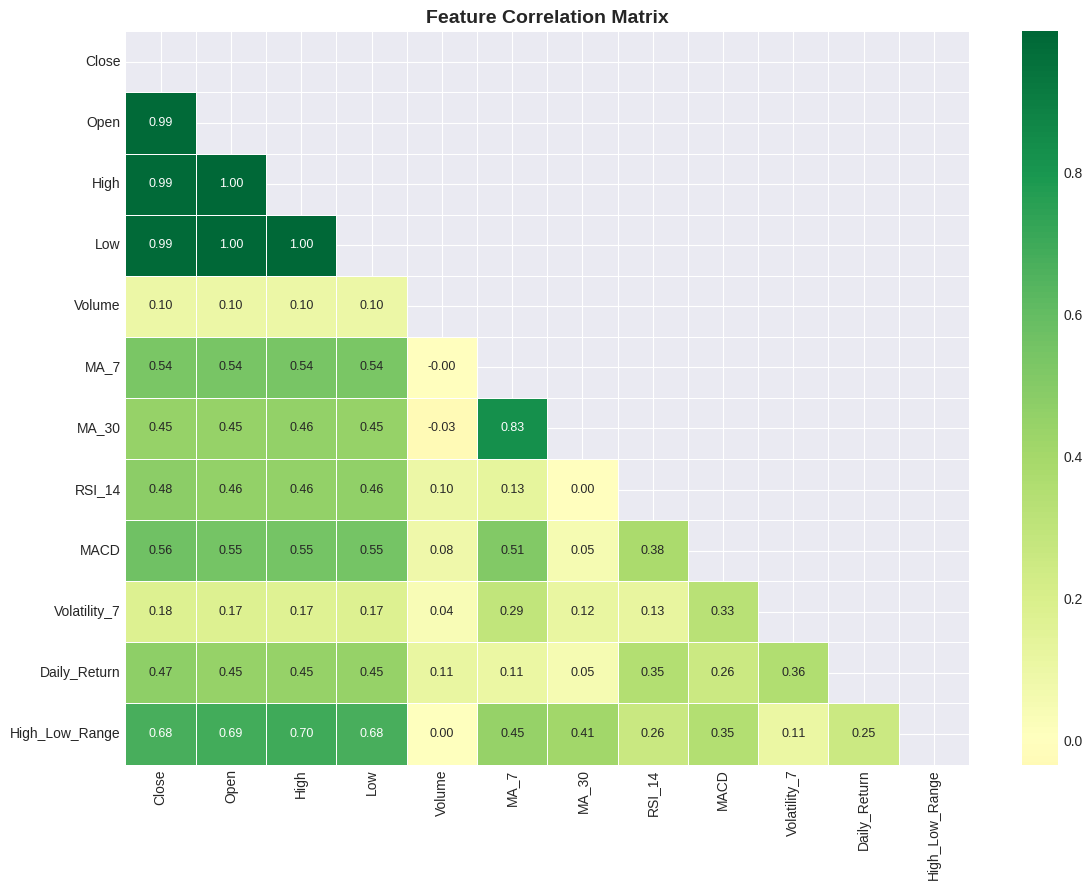

 Figure 2 saved


In [55]:
num_cols = ['Close', 'Open', 'High', 'Low', 'Volume',
            'MA_7', 'MA_30', 'RSI_14', 'MACD',
            'Volatility_7', 'Daily_Return', 'High_Low_Range']
num_cols = [c for c in num_cols if c in df.columns]

plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG}/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 2 saved')

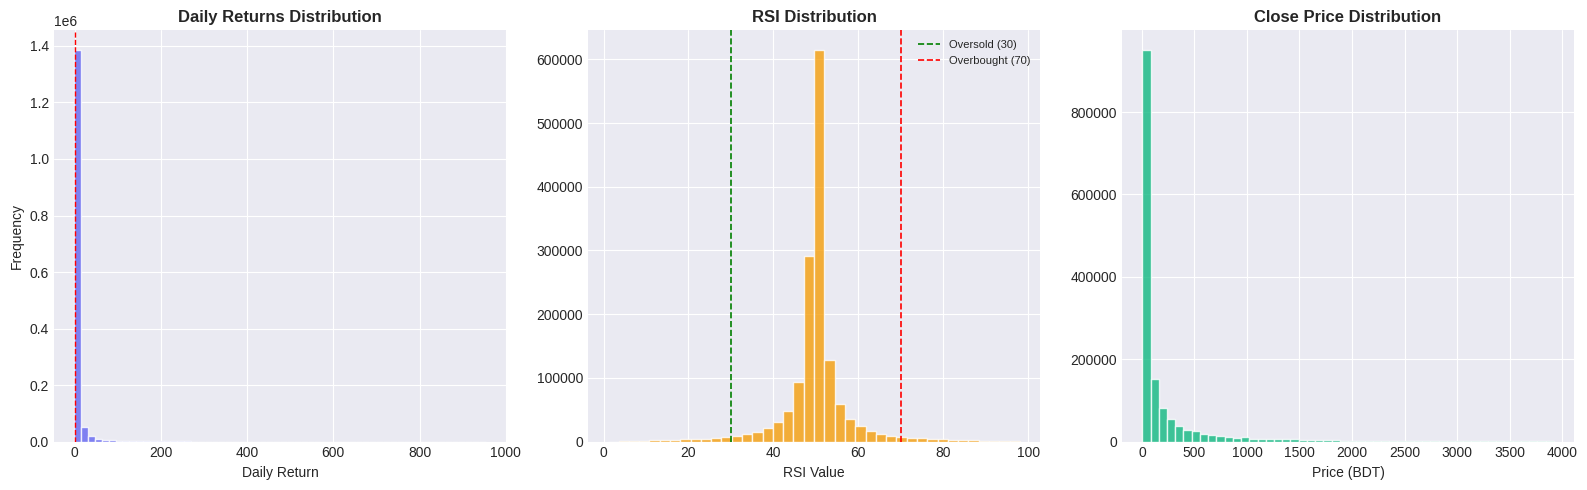

 Figure 3 saved


In [56]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Daily Returns distribution
axes[0].hist(df['Daily_Return'].dropna(), bins=60,
             color='#6366f1', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Daily Returns Distribution', fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

# RSI distribution
axes[1].hist(df['RSI_14'].dropna(), bins=40,
             color='#f59e0b', alpha=0.8, edgecolor='white')
axes[1].axvline(30, color='green', linestyle='--', linewidth=1.2, label='Oversold (30)')
axes[1].axvline(70, color='red',   linestyle='--', linewidth=1.2, label='Overbought (70)')
axes[1].set_title('RSI Distribution', fontweight='bold')
axes[1].set_xlabel('RSI Value')
axes[1].legend(fontsize=8)

# Close price distribution
axes[2].hist(df['Close'].dropna(), bins=50,
             color='#10b981', alpha=0.8, edgecolor='white')
axes[2].set_title('Close Price Distribution', fontweight='bold')
axes[2].set_xlabel('Price (BDT)')

plt.tight_layout()
plt.savefig(f'{FIG}/03_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 3 saved')

<Figure size 1400x600 with 0 Axes>

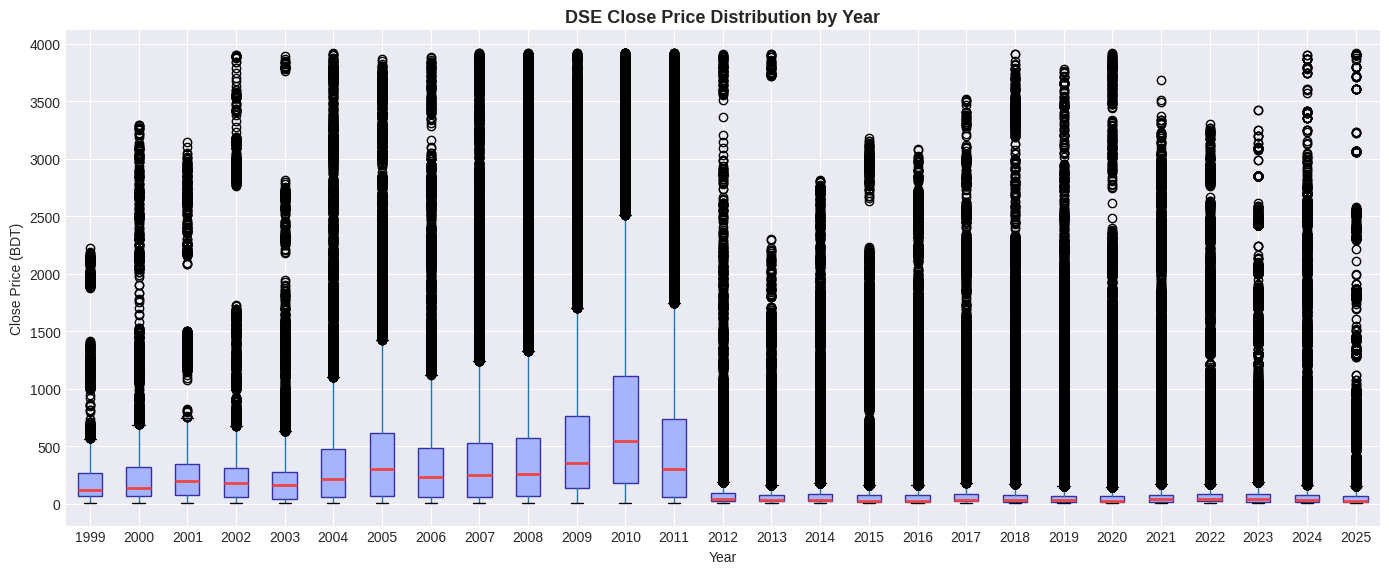

 Figure 4 saved


In [57]:
df['Year'] = df['Date'].dt.year

plt.figure(figsize=(14, 6))
df.boxplot(column='Close', by='Year', figsize=(14, 6),
           patch_artist=True,
           boxprops=dict(facecolor='#a5b4fc', color='#3730a3'),
           medianprops=dict(color='#ef4444', linewidth=2))
plt.suptitle('')
plt.title('DSE Close Price Distribution by Year', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Close Price (BDT)')
plt.tight_layout()
plt.savefig(f'{FIG}/04_yearly_price_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 4 saved')

In [58]:

df.drop(columns=['Year'], inplace=True, errors='ignore')

SAVE = f'{PROC}/dse_stock_processed.csv'
df.to_csv(SAVE, index=False)

print(' Processed stock data saved!')
print(f'Path: {SAVE}')
print(f'Shape: {df.shape}')
print(f'Features: {df.columns.tolist()}')


 Processed stock data saved!
Path: /content/drive/MyDrive/DSE_Thesis/data/processed/dse_stock_processed.csv
Shape: (1493655, 19)
Features: ['Trading_Code', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'MA_7', 'MA_30', 'MA_90', 'Daily_Return', 'Volatility_7', 'Volatility_30', 'High_Low_Range', 'Price_Change', 'Price_Change_Pct', 'RSI_14', 'MACD', 'MACD_Signal']


In [59]:
# ──checking which stocks have the most data in the 2014–2022 overlap window ──

df_all = pd.read_csv(f'{BASE}/data/processed/dse_stock_processed.csv',
                     parse_dates=['Date'])

# Filter to the exact period covered by news data
df_overlap = df_all[(df_all['Date'] >= '2014-03-03') &
                    (df_all['Date'] <= '2022-08-05')]

stock_counts = df_overlap.groupby('Trading_Code').size().sort_values(ascending=False)

print('Top 20 stocks by trading days available (2014–2022):')
print(stock_counts.head(20))
print(f'\nTotal stocks available: {stock_counts.shape[0]}')



Top 20 stocks by trading days available (2014–2022):
Trading_Code
BDWELDING     1991
EHL           1990
TRUSTB1MF     1990
BSCCL         1989
SQURPHARMA    1989
JAMUNAOIL     1989
DSHGARME      1989
ANLIMAYARN    1989
POWERGRID     1989
PADMAOIL      1989
MPETROLEUM    1989
TITASGAS      1989
ACIFORMULA    1988
ISLAMIBANK    1988
ISLAMICFIN    1988
IBNSINA       1988
PUBALIBANK    1988
ACTIVEFINE    1988
FUWANGFOOD    1988
AFTABAUTO     1988
dtype: int64

Total stocks available: 421


In [60]:
#  Filterring to ONE stock

STOCK = 'SQURPHARMA'

df_one = df_all[(df_all['Trading_Code'] == STOCK) &
                (df_all['Date'] >= '2014-03-03') &
                (df_all['Date'] <= '2022-08-05')].copy()
df_one.reset_index(drop=True, inplace=True)

print(f'Selected stock  : {STOCK}')
print(f'Total rows      : {len(df_one):,}')
print(f'Date range      : {df_one["Date"].min().date()} → {df_one["Date"].max().date()}')
print(f'Columns         : {df_one.columns.tolist()}')

df_one.to_csv(f'{PROC}/dse_stock_processed.csv', index=False)
print(f'\n Saved! Processed CSV now contains only {STOCK} data.')
df_one.head()


Selected stock  : SQURPHARMA
Total rows      : 1,989
Date range      : 2014-03-03 → 2022-08-05
Columns         : ['Trading_Code', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'MA_7', 'MA_30', 'MA_90', 'Daily_Return', 'Volatility_7', 'Volatility_30', 'High_Low_Range', 'Price_Change', 'Price_Change_Pct', 'RSI_14', 'MACD', 'MACD_Signal']

 Saved! Processed CSV now contains only SQURPHARMA data.


,Trading_Code,Date,Open,High,Low,Close,Volume,MA_7,MA_30,MA_90,Daily_Return,Volatility_7,Volatility_30,High_Low_Range,Price_Change,Price_Change_Pct,RSI_14,MACD,MACD_Signal
0,SQURPHARMA,2014-03-03,266.6,275.1,266.5,274.3,1537360.0,87.642857,202.286667,145.953333,6.314667,3.792421,9.149620,8.6,7.7,2.888222,51.717039,-30.784716,-28.297516
1,SQURPHARMA,2014-03-04,275.1,279.5,273.5,278.5,648760.0,72.528571,109.726667,126.988889,10.460905,4.176430,11.136341,6.0,3.4,1.235914,55.711321,-3.844841,-8.663499
2,SQURPHARMA,2014-03-06,278.2,279.9,273.4,274.5,339470.0,231.085714,188.307333,110.579111,2.679625,23.140423,13.212251,6.5,-3.7,-1.329978,52.314055,-4.097117,16.090225
3,SQURPHARMA,2014-03-07,280.0,280.8,277.9,279.8,215170.0,92.557143,69.886667,97.166889,0.531472,1.579416,4.204281,2.9,-0.2,-0.071429,53.393861,22.824632,5.393390
4,SQURPHARMA,2014-03-08,253.2,255.0,252.5,253.1,301420.0,61.542857,102.681667,131.328333,7.818815,3.148190,10.989499,2.5,-0.1,-0.039494,45.999090,4.516344,8.262107


In [61]:
!pip install transformers torch sentencepiece -q

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm
tqdm.pandas()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


# Loading the combined news CSV saved in Phase 1
df_news = pd.read_csv(f'{BASE}/data/raw/bangla_financial_news_combined.csv',
                      parse_dates=['Date'])
print(f'\n Loaded {len(df_news):,} news articles')
print(f'Columns : {df_news.columns.tolist()}')
print(f'Date range: {df_news["Date"].min().date()} → {df_news["Date"].max().date()}')
df_news.head(3)

Device: cuda

 Loaded 7,469 news articles
Columns : ['Serial', 'Title', 'Date', 'Author', 'News']
Date range: 2014-03-03 → 2022-08-05


,Serial,Title,Date,Author,News
0,1,শেয়ারবাজারে ব্যাংকগুলোর বিনিয়োগের হিসাব ক্রয়...,2022-08-05,ইত্তেফাক রিপোর্ট,এখন থেকে শেয়ারবাজারে ব্যাংকগুলোর বিনিয়োগের হ...
1,10,জুলাইয়ে রপ্তানি প্রবৃদ্ধি ১৫ শতাংশ,2022-08-03,ইত্তেফাক রিপোর্ট,অর্থবছরের শুরুতে রপ্তানিতে সুখবর মিলল। চলতি ২০...
2,100,তিতা খাওয়াই বাঁশও পাঠাই,2022-07-03,সাইদুল ইসলাম,বাংলাদেশ থেকে রপ্তানি করা পণ্যের সংখ্যা কত এ প...


In [62]:
# Loading BanglaBERT sentiment model
MODEL_NAME = 'SayedShaun/bangla-classifier-binary'
USE_BERT   = False

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
    model.eval()
    if device == 'cuda':
        model = model.cuda()
    print(f' BanglaBERT sentiment model loaded!')
    print(f'Labels: {model.config.id2label}')
    print(f'Note: LABEL_0 = negative, LABEL_1 = positive')
    USE_BERT = True
except Exception as e:
    print(f'  BanglaBERT failed to load: {e}')
    print('   Using keyword-based sentiment instead (see next cell)')
    USE_BERT = False


if USE_BERT:
    test_neg = tokenizer("এটা যে এত খারাপ আগে জানতাম না।", return_tensors='pt', truncation=True, max_length=128)
    if device == 'cuda':
        test_neg = {k: v.cuda() for k, v in test_neg.items()}
    with torch.no_grad():
        out = model(**test_neg)
    print(f'\nTest (negative sentence) → predicted label: {out.logits.argmax(-1).item()}')
    print('(Should print 0 for negative)')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 BanglaBERT sentiment model loaded!
Labels: {0: 'LABEL_0', 1: 'LABEL_1'}
Note: LABEL_0 = negative, LABEL_1 = positive

Test (negative sentence) → predicted label: 0
(Should print 0 for negative)


In [63]:
# Bangla financial keyword
POSITIVE = ['বেড়েছে','ঊর্ধ্বমুখী','বৃদ্ধি','লাভ','মুনাফা','ইতিবাচক',
            'উন্নতি','প্রবৃদ্ধি','রেকর্ড','সর্বোচ্চ','তেজি','চাঙা',
            'বাড়ছে','শক্তিশালী','পুনরুদ্ধার','বিনিয়োগ বৃদ্ধি']

NEGATIVE = ['কমেছে','নিম্নমুখী','হ্রাস','লোকসান','পতন','নেতিবাচক',
            'সংকট','কমছে','দরপতন','ধস','ক্ষতি','মন্দা',
            'বিক্রির চাপ','অস্থিরতা','ব্যর্থ','নামছে']

def keyword_sentiment(text):
    if not isinstance(text, str): return 0.0
    pos   = sum(1 for w in POSITIVE if w in text)
    neg   = sum(1 for w in NEGATIVE if w in text)
    total = pos + neg
    return 0.0 if total == 0 else (pos - neg) / total

def bert_score(text):
    try:
        inputs = tokenizer(str(text)[:512], return_tensors='pt',
                           truncation=True, max_length=256, padding=True)
        if device == 'cuda':
            inputs = {k: v.cuda() for k, v in inputs.items()}
        with torch.no_grad():
            probs = torch.softmax(model(**inputs).logits, dim=-1).cpu().numpy()[0]
        return float(probs[-1] - probs[0])
    except:
        return keyword_sentiment(text)


print('Positive test:', keyword_sentiment('শেয়ারবাজারে সূচক বেড়েছে মুনাফা বৃদ্ধি'))
print('Negative test:', keyword_sentiment('শেয়ারবাজারে দরপতন লোকসান কমেছে'))
print(' Sentiment functions ready!')


Positive test: 1.0
Negative test: -1.0
 Sentiment functions ready!


In [64]:


df_news['text'] = (df_news['Title'].fillna('') + ' ' +
                   df_news['News'].fillna('').str[:200])

print(f'Scoring {len(df_news):,} articles...')
print(f'Method: {"BanglaBERT" if USE_BERT else "Keyword lexicon"}')

if USE_BERT:
    df_news['sentiment_score'] = df_news['text'].progress_apply(bert_score)
else:
    df_news['sentiment_score'] = df_news['text'].progress_apply(keyword_sentiment)

print('\n Scoring complete!')
print('Score distribution (−1 = very negative, 0 = neutral, +1 = very positive):')
print(df_news['sentiment_score'].describe())
df_news[['Title','Date','sentiment_score']].head(5)


Scoring 7,469 articles...
Method: BanglaBERT


  0%|          | 0/7469 [00:00<?, ?it/s]


 Scoring complete!
Score distribution (−1 = very negative, 0 = neutral, +1 = very positive):
count    7469.000000
mean        0.298748
std         0.791458
min        -0.983253
25%        -0.691722
50%         0.776677
75%         0.946069
max         0.987904
Name: sentiment_score, dtype: float64


,Title,Date,sentiment_score
0,শেয়ারবাজারে ব্যাংকগুলোর বিনিয়োগের হিসাব ক্রয়...,2022-08-05,0.920992
1,জুলাইয়ে রপ্তানি প্রবৃদ্ধি ১৫ শতাংশ,2022-08-03,0.961035
2,তিতা খাওয়াই বাঁশও পাঠাই,2022-07-03,-0.109240
3,ভ্যাট নিবন্ধন বেড়েছে ৬৯ শতাংশ,2021-08-23,0.601628
4,সিলেটে ডিবিএল গ্রুপের ইন্ডাষ্ট্রিয়াল পার্কের য...,2021-08-22,0.940384


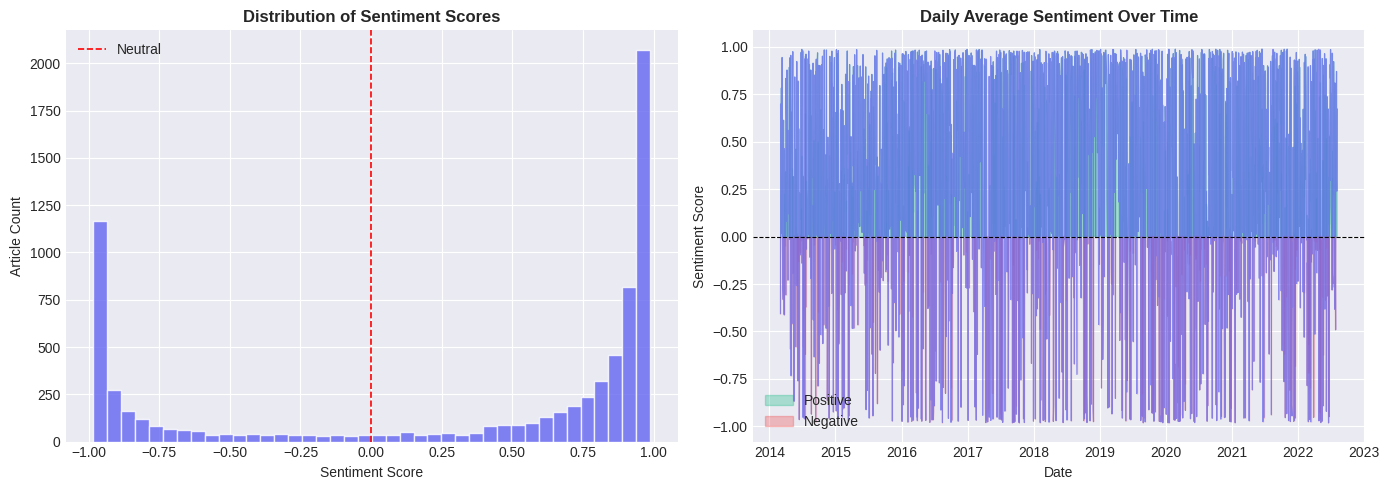

 Figure 5 saved


In [65]:
# Plot sentiment distribution and trend
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of sentiment scores
axes[0].hist(df_news['sentiment_score'], bins=40, color='#6366f1', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Neutral')
axes[0].set_title('Distribution of Sentiment Scores', fontweight='bold')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Article Count')
axes[0].legend()

# Daily average sentiment over time
daily_plot = df_news.groupby(df_news['Date'].dt.date)['sentiment_score'].mean().reset_index()
daily_plot['Date'] = pd.to_datetime(daily_plot['Date'])
axes[1].plot(daily_plot['Date'], daily_plot['sentiment_score'], color='#6366f1', linewidth=0.8, alpha=0.7)
axes[1].fill_between(daily_plot['Date'], daily_plot['sentiment_score'], 0,
                     where=daily_plot['sentiment_score'] >= 0, alpha=0.3, color='#10b981', label='Positive')
axes[1].fill_between(daily_plot['Date'], daily_plot['sentiment_score'], 0,
                     where=daily_plot['sentiment_score'] < 0,  alpha=0.3, color='#ef4444', label='Negative')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Daily Average Sentiment Over Time', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sentiment Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIG}/05_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 5 saved')


In [66]:
daily = df_news.groupby(df_news['Date'].dt.date).agg(
    sentiment_mean   = ('sentiment_score', 'mean'),
    sentiment_std    = ('sentiment_score', 'std'),
    positive_count   = ('sentiment_score', lambda x: (x > 0.1).sum()),
    negative_count   = ('sentiment_score', lambda x: (x < -0.1).sum()),
    news_count       = ('sentiment_score', 'count')
).reset_index()

daily.rename(columns={'Date': 'Date'}, inplace=True)
daily['Date']            = pd.to_datetime(daily['Date'])
daily['sentiment_std']   = daily['sentiment_std'].fillna(0)
daily['sentiment_ratio'] = ((daily['positive_count'] - daily['negative_count']) /
                             daily['news_count'].clip(lower=1))

print(f'Daily sentiment rows : {len(daily)}')
print(f'Date range           : {daily["Date"].min().date()} → {daily["Date"].max().date()}')
daily.head()


Daily sentiment rows : 2591
Date range           : 2014-03-03 → 2022-08-05


,Date,sentiment_mean,sentiment_std,positive_count,negative_count,news_count,sentiment_ratio
0,2014-03-03,-0.406658,0.928957,1,2,3,-0.333333
1,2014-03-04,0.697632,0.143703,2,0,2,1.000000
2,2014-03-05,0.200038,1.017086,2,1,3,0.333333
3,2014-03-06,0.328743,0.991240,2,1,3,0.333333
4,2014-03-08,0.781944,0.107357,2,0,2,1.000000


In [67]:
#  Merging  daily sentiment with single-stock price data
df_stock = pd.read_csv(f'{PROC}/dse_stock_processed.csv', parse_dates=['Date'])

df_merged = pd.merge(df_stock, daily, on='Date', how='left')

# Days with no news → neutral (0)
for col in ['sentiment_mean','sentiment_std','sentiment_ratio',
            'news_count','positive_count','negative_count']:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].fillna(0)

# Lagged sentiment features
df_merged['sentiment_lag1'] = df_merged['sentiment_mean'].shift(1).fillna(0)
df_merged['sentiment_ma7']  = df_merged['sentiment_mean'].rolling(7).mean().fillna(0)

FINAL = f'{PROC}/dse_with_sentiment.csv'
df_merged.to_csv(FINAL, index=False)

print(f' Final merged dataset saved!')
print(f'Path  : {FINAL}')
print(f'Shape : {df_merged.shape}')
print(f'Days with news    : {(df_merged["news_count"] > 0).sum()}')
print(f'Days without news : {(df_merged["news_count"] == 0).sum()}')
print(f'\nAll columns:')
for c in df_merged.columns: print(f'  - {c}')


 Final merged dataset saved!
Path  : /content/drive/MyDrive/DSE_Thesis/data/processed/dse_with_sentiment.csv
Shape : (1989, 27)
Days with news    : 1755
Days without news : 234

All columns:
  - Trading_Code
  - Date
  - Open
  - High
  - Low
  - Close
  - Volume
  - MA_7
  - MA_30
  - MA_90
  - Daily_Return
  - Volatility_7
  - Volatility_30
  - High_Low_Range
  - Price_Change
  - Price_Change_Pct
  - RSI_14
  - MACD
  - MACD_Signal
  - sentiment_mean
  - sentiment_std
  - positive_count
  - negative_count
  - news_count
  - sentiment_ratio
  - sentiment_lag1
  - sentiment_ma7


In [68]:
!pip install statsmodels tensorflow -q

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv(f'{PROC}/dse_with_sentiment.csv', parse_dates=['Date'])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df["Date"].min().date()} → {df["Date"].max().date()}')

# ── FIX: avoid data leakage for Linear Regression / Random Forest ──
df['Target_Close'] = df['Close'].shift(-1)
df = df.dropna(subset=['Target_Close']).reset_index(drop=True)
print(f'After creating next-day target: {df.shape}  (lost 1 row at the end)')

BASE_F = ['Open','High','Low','Close','Volume','MA_7','MA_30','MA_90',
          'RSI_14','MACD','Volatility_7','Daily_Return','High_Low_Range']
SENT_F = BASE_F + ['sentiment_mean','sentiment_std','sentiment_ratio',
                   'news_count','sentiment_lag1','sentiment_ma7']

BASE_F = [c for c in BASE_F if c in df.columns]
SENT_F = [c for c in SENT_F if c in df.columns]

TARGET_TABULAR = 'Target_Close'  # used by Linear Regression & Random Forest
TARGET_SEQ     = 'Close'         # used by LSTM

split    = int(len(df) * 0.8)
train_df = df.iloc[:split].copy()
test_df  = df.iloc[split:].copy()

ALL_RESULTS = {}

print(f'\nTrain: {len(train_df)} rows  ({train_df["Date"].min().date()} → {train_df["Date"].max().date()})')
print(f'Test : {len(test_df)} rows  ({test_df["Date"].min().date()} → {test_df["Date"].max().date()})')
print(f'Base features    : {len(BASE_F)}')
print(f'Sentiment features: {len(SENT_F)}')

Dataset shape : (1989, 27)
Date range    : 2014-03-03 → 2022-08-05
After creating next-day target: (1988, 28)  (lost 1 row at the end)

Train: 1590 rows  (2014-03-03 → 2020-11-30)
Test : 398 rows  (2020-12-01 → 2022-08-04)
Base features    : 13
Sentiment features: 19


In [69]:
# ── Model 1: Linear Regression  |  Model 2: Random Forest ──
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

def evaluate(y_true, y_pred, model_name, feat_label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    key  = f'{model_name}_{feat_label}'
    ALL_RESULTS[key] = {'Model': model_name,
                        'Features': 'With Sentiment' if feat_label == 'sent' else 'Base Only',
                        'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
                        'preds': y_pred, 'actuals': np.array(y_true)}
    print(f'  {model_name:20s} [{feat_label:4s}]  RMSE: {rmse:.4f}   MAE: {mae:.4f}')

print('Linear Regression (predicting next-day close):')
for feats, label in [(BASE_F,'base'),(SENT_F,'sent')]:
    sc     = StandardScaler()
    X_tr   = sc.fit_transform(train_df[feats].fillna(0))
    X_te   = sc.transform(test_df[feats].fillna(0))
    preds  = LinearRegression().fit(X_tr, train_df[TARGET_TABULAR]).predict(X_te)
    evaluate(test_df[TARGET_TABULAR].values, preds, 'LinearRegression', label)

print('\nRandom Forest (predicting next-day close):')
for feats, label in [(BASE_F,'base'),(SENT_F,'sent')]:
    rf     = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
    rf.fit(train_df[feats].fillna(0), train_df[TARGET_TABULAR])
    preds  = rf.predict(test_df[feats].fillna(0))
    evaluate(test_df[TARGET_TABULAR].values, preds, 'RandomForest', label)
    if label == 'sent':
        fi = pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False)
        print('  Top 5 features:', fi.head(5).to_dict())

Linear Regression (predicting next-day close):
  LinearRegression     [base]  RMSE: 9.0412   MAE: 6.2595
  LinearRegression     [sent]  RMSE: 9.0702   MAE: 6.2592

Random Forest (predicting next-day close):
  RandomForest         [base]  RMSE: 13.9317   MAE: 10.5829
  RandomForest         [sent]  RMSE: 12.8668   MAE: 9.7344
  Top 5 features: {'High': 0.37133798048277916, 'Low': 0.21475898795606535, 'Close': 0.16750077532018662, 'Open': 0.14715165499885513, 'Volume': 0.013966125073112437}


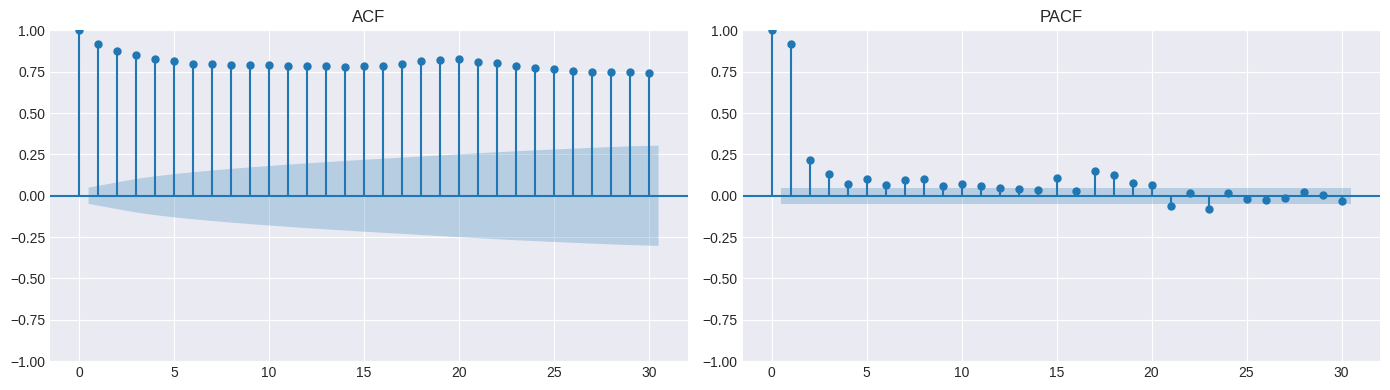

Figure 6 saved 

 ARIMA(5,1,2) — fitting... (takes ~2 minutes)
  ARIMA                [base]  RMSE: 24.8416   MAE: 22.7013


In [70]:
# Model 3: ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

close   = df['Close'].values
tr_arr  = close[:split]
te_arr  = close[split:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(tr_arr,  lags=30, ax=ax1, title='ACF')
plot_pacf(tr_arr, lags=30, ax=ax2, title='PACF')
plt.tight_layout()
plt.savefig(f'{FIG}/06_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved ')

print('\n ARIMA(5,1,2) — fitting... (takes ~2 minutes)')
arima_fit = ARIMA(tr_arr, order=(5, 1, 2)).fit()
preds     = arima_fit.forecast(steps=len(te_arr))
evaluate(te_arr, preds, 'ARIMA', 'base')



In [71]:
# Model 4: LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

SEQ = 30

def run_lstm(feats, label):
    print(f'  Training LSTM [{label}]...')
    cols   = [TARGET_SEQ] + [f for f in feats if f != TARGET_SEQ and f in df.columns]
    data   = df[cols].fillna(0).values
    sc     = MinMaxScaler()
    scaled = sc.fit_transform(data)
    X, y   = [], []
    for i in range(SEQ, len(scaled)):
        X.append(scaled[i-SEQ:i]); y.append(scaled[i, 0])
    X, y   = np.array(X), np.array(y)
    t      = split - SEQ
    X_tr, X_te = X[:t], X[t:]
    y_tr, y_te = y[:t], y[t:]

    mdl = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(SEQ, X.shape[2])),
        Dropout(0.2),
        LSTM(32), Dropout(0.2),
        Dense(16, activation='relu'), Dense(1)
    ])
    mdl.compile(optimizer='adam', loss='huber')
    mdl.fit(X_tr, y_tr, epochs=60, batch_size=32, validation_split=0.1, verbose=0,
            callbacks=[EarlyStopping(patience=8, restore_best_weights=True)])

    raw  = mdl.predict(X_te, verbose=0).flatten()
    d1   = np.zeros((len(raw), data.shape[1])); d1[:,0] = raw
    d2   = np.zeros((len(y_te), data.shape[1])); d2[:,0] = y_te
    preds   = sc.inverse_transform(d1)[:,0]
    actuals = sc.inverse_transform(d2)[:,0]
    mdl.save(f'{BASE}/models/lstm_{label}.h5')
    evaluate(actuals, preds, 'LSTM', label)

run_lstm(BASE_F, 'base')
run_lstm(SENT_F, 'sent')

  Training LSTM [base]...


  LSTM                 [base]  RMSE: 9.5044   MAE: 7.3101
  Training LSTM [sent]...


  LSTM                 [sent]  RMSE: 10.0491   MAE: 7.6381


In [72]:
rows = [{'Model': v['Model'], 'Feature Set': v['Features'],
         'RMSE': v['RMSE'], 'MAE': v['MAE']}
        for k, v in ALL_RESULTS.items() if 'preds' in v]

df_res = pd.DataFrame(rows).sort_values('RMSE')

print('=' * 58)
print('MODEL COMPARISON  (sorted by RMSE — lower is better)')
print('=' * 58)
print(df_res.to_string(index=False))
print('\nBest model:', df_res.iloc[0]['Model'], '|', df_res.iloc[0]['Feature Set'])

df_res.to_csv(f'{BASE}/results/model_comparison.csv', index=False)
df_res.to_excel(f'{BASE}/results/model_comparison.xlsx', index=False)

best_key  = [k for k, v in ALL_RESULTS.items()
             if 'preds' in v and v['Model'] == df_res.iloc[0]['Model']
             and v['Features'] == df_res.iloc[0]['Feature Set']][0]
n         = len(ALL_RESULTS[best_key]['actuals'])
pd.DataFrame({
    'Date'           : test_df['Date'].reset_index(drop=True).iloc[:n].values,
    'Actual_Close'   : ALL_RESULTS[best_key]['actuals'],
    'Predicted_Close': ALL_RESULTS[best_key]['preds'],
    'Sentiment_Score': test_df['sentiment_mean'].reset_index(drop=True).iloc[:n].values
}).to_excel(f'{BASE}/results/powerbi_predictions.xlsx', index=False)

print('\n Saved: results/model_comparison.csv')
print(' Saved: results/model_comparison.xlsx')
print(' Saved: results/powerbi_predictions.xlsx  ')


MODEL COMPARISON  (sorted by RMSE — lower is better)
           Model    Feature Set    RMSE     MAE
LinearRegression      Base Only  9.0412  6.2595
LinearRegression With Sentiment  9.0702  6.2592
            LSTM      Base Only  9.5044  7.3101
            LSTM With Sentiment 10.0491  7.6381
    RandomForest With Sentiment 12.8668  9.7344
    RandomForest      Base Only 13.9317 10.5829
           ARIMA      Base Only 24.8416 22.7013

Best model: LinearRegression | Base Only

 Saved: results/model_comparison.csv
 Saved: results/model_comparison.xlsx
 Saved: results/powerbi_predictions.xlsx  


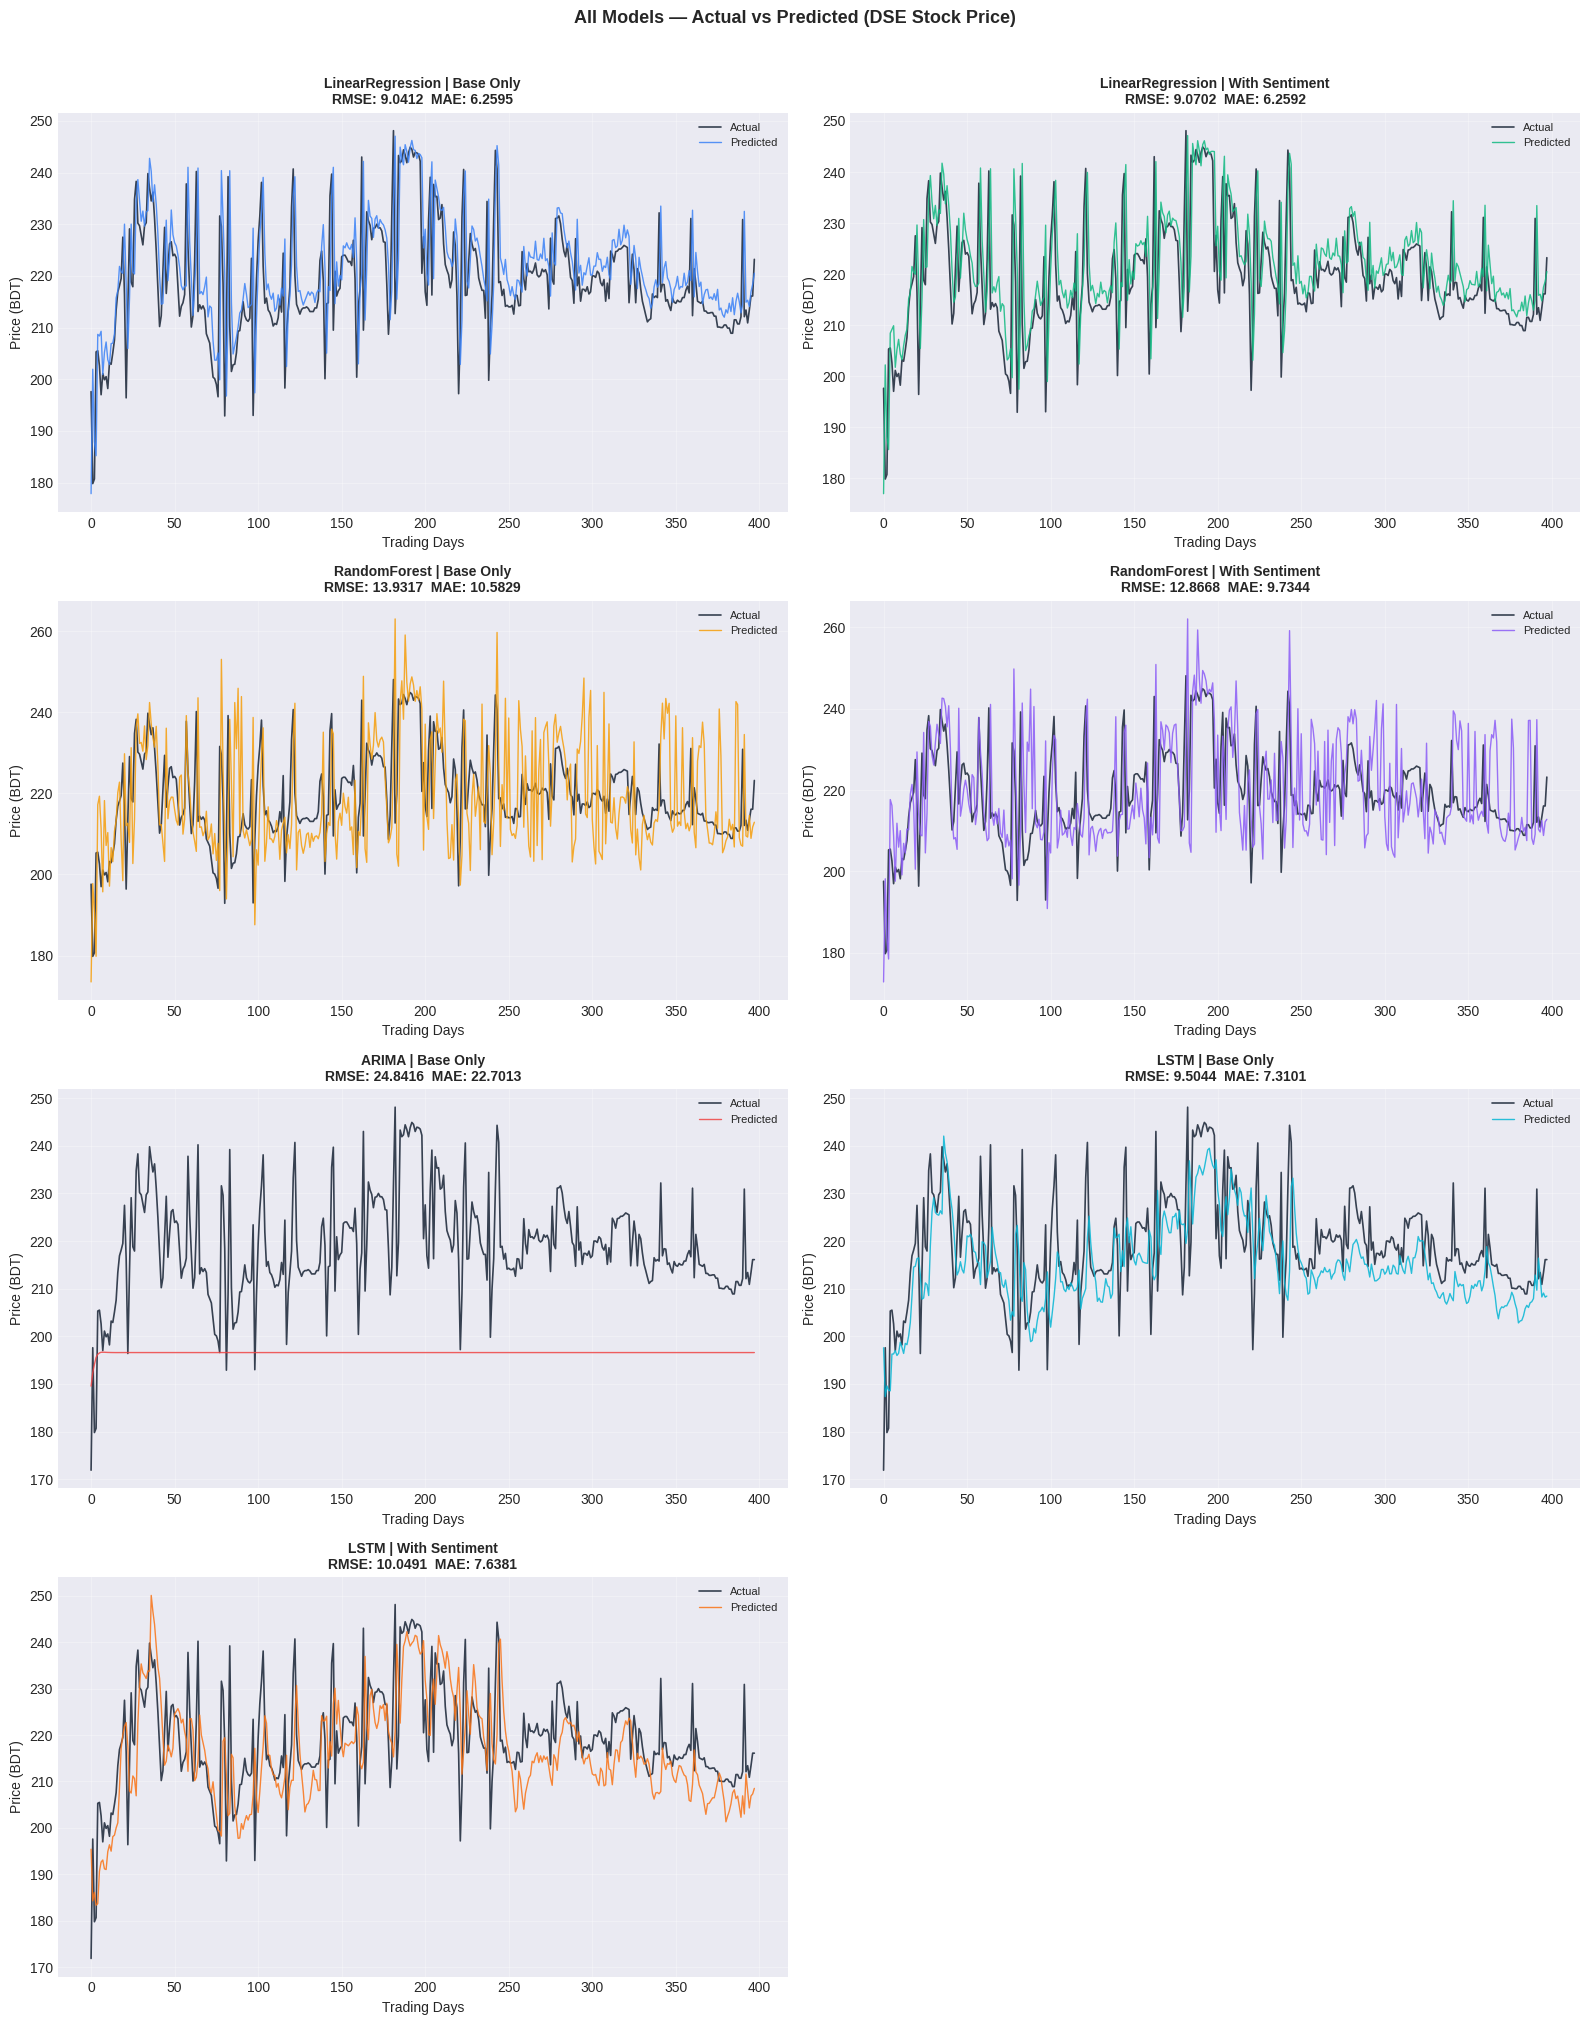

 Figure 7 saved


In [73]:
#  Actual vs Predicted plots for all models
plot_keys = [k for k, v in ALL_RESULTS.items() if 'preds' in v]
n_plots   = len(plot_keys)
n_rows    = (n_plots + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
axes      = axes.flatten()

COLS = ['#3b82f6','#10b981','#f59e0b','#8b5cf6','#ef4444','#06b6d4','#f97316']

for i, k in enumerate(plot_keys):
    r   = ALL_RESULTS[k]
    ax  = axes[i]
    n   = min(len(r['actuals']), len(r['preds']))
    ax.plot(r['actuals'][:n], color='#374151', lw=1.2, label='Actual')
    ax.plot(r['preds'][:n],   color=COLS[i],   lw=1,   label='Predicted', alpha=0.85)
    ax.set_title(f"{r['Model']} | {r['Features']}\nRMSE: {r['RMSE']}  MAE: {r['MAE']}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Trading Days'); ax.set_ylabel('Price (BDT)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)): axes[j].set_visible(False)
plt.suptitle('All Models — Actual vs Predicted (DSE Stock Price)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG}/07_all_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 7 saved')


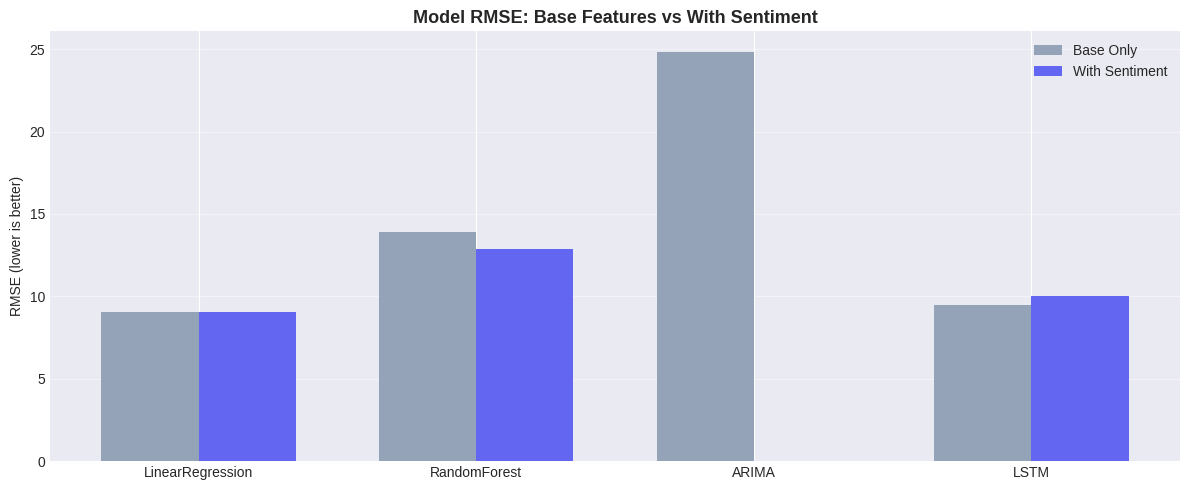

 Figure 8 saved


In [74]:
#  RMSE bar chart — base vs with-sentiment comparison
df_plot = pd.DataFrame([{'Model': v['Model'], 'Features': v['Features'], 'RMSE': v['RMSE']}
                         for k, v in ALL_RESULTS.items() if 'preds' in v])

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(df_plot['Model'].nunique())
models  = df_plot['Model'].unique()
base    = df_plot[df_plot['Features'] == 'Base Only'].set_index('Model')['RMSE']
sent    = df_plot[df_plot['Features'] == 'With Sentiment'].set_index('Model')['RMSE']
w       = 0.35

ax.bar(x - w/2, [base.get(m, 0) for m in models], w, label='Base Only',      color='#94a3b8')
ax.bar(x + w/2, [sent.get(m, 0) for m in models], w, label='With Sentiment', color='#6366f1')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel('RMSE (lower is better)')
ax.set_title('Model RMSE: Base Features vs With Sentiment', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{FIG}/08_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure 8 saved')

